In [1]:
from pathlib import Path
import numpy as np

dataset_path = Path("datasets/base_params_300_periods")

str_jpc_config = (dataset_path / "jpc_config.txt").read_text()
str_quantum_parameters = (dataset_path / "quantum_parameters.txt").read_text()
str_encoding = (dataset_path / "encoding.txt").read_text()

print(str_jpc_config)
print(str_quantum_parameters)
print(str_encoding)

JPCConfig(
    DIM_A=10,
    DIM_B=10,
    OMEGA_A=10000.0,
    OMEGA_B=9000.0,
    KAPPA_A=17,
    KAPPA_B=21,
    K_AA=0.1,
    K_BB=0.1,
    K_AB=0.05,
    DRIVE_DURATION=0.04,
    MEASURE_RESOLUTION=10,
    SIMULATION_RESOLUTION=10
)

QuantumParameters(
    g_conv=900,
    g_sq=180,
    epsilon_a=170,
    epsilon_b=170,
    delta_a=0,
    delta_b=0
)

Encoding(
    encoding_parameters=('g_sq',),
    encoding_function=Linear()
)



In [2]:
X = np.load(dataset_path / "X.npy")
Y = np.load(dataset_path / "Y.npy")

X.shape, Y.shape

((30, 80), (30, 80, 1))

In [3]:
F_quad = np.load(dataset_path / "f_quad.npy")
F_quad_poly = np.load(dataset_path / "f_quad_poly.npy")
F_probas = np.load(dataset_path / "f_probas.npy")

F_quad.shape, F_quad_poly.shape, F_probas.shape

((30, 80, 40), (30, 80, 140), (30, 80, 40))

In [4]:
nb_batches_train = 25

X_train, X_test = X[:nb_batches_train], X[nb_batches_train:]
Y_train, Y_test = Y[:nb_batches_train], Y[nb_batches_train:].reshape(-1, Y.shape[-1])

F_train_quad, F_test_quad = F_quad[:nb_batches_train], F_quad[nb_batches_train:].reshape(-1, F_quad.shape[-1])
F_train_quad_poly, F_test_quad_poly = F_quad_poly[:nb_batches_train], F_quad_poly[nb_batches_train:].reshape(-1, F_quad_poly.shape[-1])
F_train_probas, F_test_probas = F_probas[:nb_batches_train], F_probas[nb_batches_train:].reshape(-1, F_probas.shape[-1])

F_train_quad.shape, F_train_quad_poly.shape, F_train_probas.shape

((25, 80, 40), (25, 80, 140), (25, 80, 40))

In [5]:
from lab.config.neural_networks import linear
from zeroth import first_order

linear.summary()

neural_network_quad = first_order.FirstOrderNeuralNetwork(config=linear,
                                                          input_dim=F_quad.shape[-1],
                                                          output_dim=2)

neural_network_quad_poly = first_order.FirstOrderNeuralNetwork(config=linear,
                                                               input_dim=F_quad_poly.shape[-1],
                                                               output_dim=2)

neural_network_probas = first_order.FirstOrderNeuralNetwork(linear,
                                                            input_dim=F_probas.shape[-1],
                                                            output_dim=2)


NeuralNetworkConfig(
    name='Linear',
    hidden_dims=[],
    activations=[
        Softmax()
    ]
)


In [6]:
optimizer_config = first_order.FirstOrderAdamConfig(learning_rate=0.05,
                                                    beta1=0.9,
                                                    beta2=0.99,
                                                    epsilon=1e-8)

optimizer_quad = optimizer_config.instantiate()
optimizer_quad_poly = optimizer_config.instantiate()
optimizer_probas = optimizer_config.instantiate()

In [7]:
from zeroth.losses import CrossEntropy

loss = CrossEntropy()

def train_step(_F_quad: np.ndarray, _F_quad_poly: np.ndarray, _F_probas: np.ndarray, _Y: np.ndarray) -> tuple[float, float, float]:
    loss_quad = optimizer_quad.do_descent(neural_network=neural_network_quad,
                                          loss=loss,
                                          X=_F_quad,
                                          Y_true=_Y)

    loss_quad_poly = optimizer_quad_poly.do_descent(neural_network=neural_network_quad_poly,
                                                    loss=loss,
                                                    X=_F_quad_poly,
                                                    Y_true=_Y)

    loss_quad_probas = optimizer_probas.do_descent(neural_network=neural_network_probas,
                                                   loss=loss,
                                                   X=_F_probas,
                                                   Y_true=_Y)

    return loss_quad, loss_quad_poly, loss_quad_probas

X_train = X_train.reshape(-1)

nb_epochs = 1000

losses = np.zeros((3, nb_epochs * nb_batches_train))

for epoch in range(nb_epochs):
    for i in range(nb_batches_train):
        batch_loss = train_step(_F_quad=F_train_quad[i],
                                _F_quad_poly=F_train_quad_poly[i],
                                _F_probas=F_train_probas[i],
                                _Y=Y_train[i])
        losses[:, epoch * nb_batches_train + i] = batch_loss

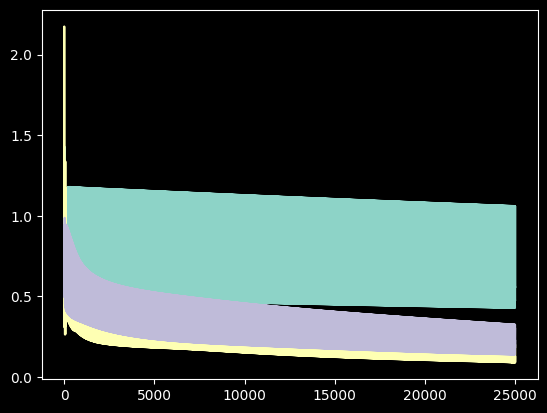

In [8]:
import matplotlib.pyplot as plt

X = range(losses.shape[-1])
plt.plot(X, losses[0])
plt.plot(X, losses[1])
plt.plot(X, losses[2])
plt.show()

In [9]:
Y_pred_quad = neural_network_quad(F_test_quad)
Y_pred_quad_poly = neural_network_quad_poly(F_test_quad_poly)
Y_pred_probas = neural_network_probas(F_test_probas)

Y_pred_quad.shape, Y_test.shape

((400, 2), (400, 1))

In [10]:
Y_pred_01_quad = np.argmax(Y_pred_quad, axis=1)
acc_quad = np.mean(Y_pred_01_quad == Y_test[:, 0])
print(f"Accuracy quadratures = {acc_quad * 1e2} %")

Y_pred_01_quad_poly = np.argmax(Y_pred_quad_poly, axis=1)
acc_quad_poly = np.mean(Y_pred_01_quad_poly == Y_test[:, 0])
print(f"Accuracy quadratures poly = {acc_quad_poly * 1e2} %")

Y_pred_01_probas = np.argmax(Y_pred_probas, axis=1)
acc_probas = np.mean(Y_pred_01_probas == Y_test[:, 0])
print(f"Accuracy probas = {acc_probas * 1e2} %")


Accuracy quadratures = 78.25 %
Accuracy quadratures poly = 94.5 %
Accuracy probas = 92.5 %


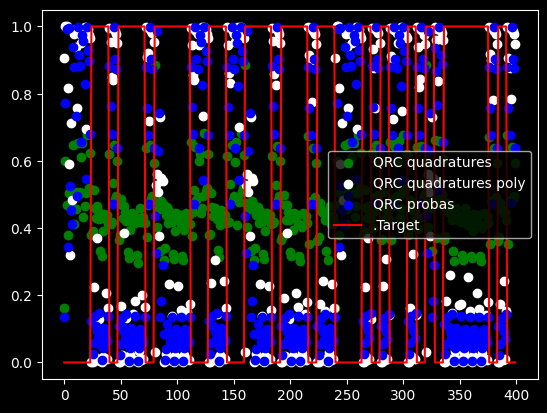

In [11]:
import matplotlib.pyplot as plt

X = range(Y_pred_quad.shape[0])
plt.scatter(X, Y_pred_quad[:, 0], label="QRC quadratures", color="g")
plt.scatter(X, Y_pred_quad_poly[:, 0], label="QRC quadratures poly", color="w")
plt.scatter(X, Y_pred_probas[:, 0], label="QRC probas", color="b")
plt.plot(X, Y_test.ravel(), label=".Target", color="r")
plt.legend()
plt.show()
